## 1. Setup

In [17]:
# 0. Import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("../src")
from prepare_data import DATASETS

def rule_violations(series, lo, hi):
    bad = series < float("-inf")
    if lo is not None:
        bad = bad | (series < lo)
    if hi is not None:
        bad = bad | (series > hi)
    return bad

In [18]:
# 1. Load
DATASET = "online_shoppers"
TARGET = DATASETS[DATASET]["target"]
CONT = DATASETS[DATASET]["continuous"]
CODES = DATASETS[DATASET]["codes"]
BOUNDS = DATASETS[DATASET]["bounds"]
MESSY_DIR = f"../data/messy/{DATASET}"
CONDITIONS = ["clean", "missing_mild", "missing_severe",
              "outlier_mild", "outlier_severe", "noise_mild", "noise_severe"]

dfs = {}
for c in CONDITIONS:
    path = f"{MESSY_DIR}/{c}/train.csv"
    dfs[c] = pd.read_csv(path)
test_df = pd.read_csv(f"../data/processed/{DATASET}/test.csv")

for c, d in dfs.items():
    print(f"{c:<16} shape={d.shape}  missing={d.isnull().mean().mean():.2%}  pos_rate={d[TARGET].mean():.3f}")
print(f"{'test':<16} shape={test_df.shape}")

clean            shape=(9864, 18)  missing=0.00%  pos_rate=0.155
missing_mild     shape=(9864, 18)  missing=8.33%  pos_rate=0.155
missing_severe   shape=(9864, 18)  missing=16.67%  pos_rate=0.155
outlier_mild     shape=(9864, 18)  missing=0.00%  pos_rate=0.155
outlier_severe   shape=(9864, 18)  missing=0.00%  pos_rate=0.155
noise_mild       shape=(9864, 18)  missing=0.00%  pos_rate=0.188
noise_severe     shape=(9864, 18)  missing=0.00%  pos_rate=0.293
test             shape=(2466, 18)


## 2. EDA

Following the protocol:
1. Basic data loading check (shape, info, columns, describe)
2. Basic descriptive stats (mean, median, std, skew)
3. Missing value profile (% and pattern)
4. Outlier profile (distribution shape, IQR count)
5. Class balance profile (check class balance)
6. Correlation matrix

In [19]:
# 1. Basic data loading (all conditions + test)
all_dfs = dfs.copy()
all_dfs["test"] = test_df

for name, d in all_dfs.items():
    print(f"\n{'='*70}\n  {name.upper()}\n{'='*70}")
    print(f"Data Shape: {d.shape}")
    print("\nData Info:")
    d.info()
    print("\nData Columns:")
    print(d.columns.tolist())
    print("\nData Description:")
    display(d.describe())


  CLEAN
Data Shape: (9864, 18)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9864 entries, 0 to 9863
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           9864 non-null   int64  
 1   Administrative_Duration  9864 non-null   float64
 2   Informational            9864 non-null   int64  
 3   Informational_Duration   9864 non-null   float64
 4   ProductRelated           9864 non-null   int64  
 5   ProductRelated_Duration  9864 non-null   float64
 6   BounceRates              9864 non-null   float64
 7   ExitRates                9864 non-null   float64
 8   PageValues               9864 non-null   float64
 9   SpecialDay               9864 non-null   float64
 10  Month                    9864 non-null   object 
 11  OperatingSystems         9864 non-null   int64  
 12  Browser                  9864 non-null   int64  
 13  Region                   9864 non-

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue
count,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000
mean,2.317620,81.241059,0.504663,34.590252,31.452758,1186.546010,0.022396,0.043313,5.944562,0.062693,2.127534,2.366788,3.152778,4.071168,0.231752,0.154704
std,3.319144,179.610421,1.275169,141.428972,43.615440,1909.252291,0.048809,0.048901,18.562169,0.201271,0.918098,1.732810,2.395939,4.015231,0.421973,0.361641
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,182.566071,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,0.000000,0.000000
50%,1.000000,8.000000,0.000000,0.000000,18.000000,600.536667,0.003110,0.025195,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,0.000000,0.000000
75%,4.000000,93.000000,0.000000,0.000000,38.000000,1474.508333,0.017081,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000,1.000000,1.000000



  MISSING_MILD
Data Shape: (9864, 18)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9864 entries, 0 to 9863
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           8878 non-null   float64
 1   Administrative_Duration  8878 non-null   float64
 2   Informational            8878 non-null   float64
 3   Informational_Duration   8878 non-null   float64
 4   ProductRelated           8878 non-null   float64
 5   ProductRelated_Duration  8878 non-null   float64
 6   BounceRates              8878 non-null   float64
 7   ExitRates                8878 non-null   float64
 8   PageValues               8878 non-null   float64
 9   SpecialDay               8878 non-null   float64
 10  Month                    9864 non-null   object 
 11  OperatingSystems         8878 non-null   float64
 12  Browser                  8878 non-null   float64
 13  Region                   88

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue
count,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,9864.000000
mean,2.305812,81.417159,0.517684,34.536653,31.473981,1189.616697,0.022200,0.043491,5.899054,0.063348,2.130322,2.366975,3.152512,4.063190,0.232147,0.154704
std,3.299355,177.513394,1.291767,141.176950,43.763862,1926.997947,0.048573,0.049181,18.580561,0.202200,0.920656,1.731120,2.397229,4.009389,0.422226,0.361641
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,183.808333,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,0.000000,0.000000
50%,1.000000,8.000000,0.000000,0.000000,18.000000,601.767424,0.003083,0.025431,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,0.000000,0.000000
75%,4.000000,94.600000,0.000000,0.000000,38.000000,1478.830952,0.016667,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000,1.000000,1.000000



  MISSING_SEVERE
Data Shape: (9864, 18)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9864 entries, 0 to 9863
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           7891 non-null   float64
 1   Administrative_Duration  7891 non-null   float64
 2   Informational            7891 non-null   float64
 3   Informational_Duration   7891 non-null   float64
 4   ProductRelated           7891 non-null   float64
 5   ProductRelated_Duration  7891 non-null   float64
 6   BounceRates              7891 non-null   float64
 7   ExitRates                7891 non-null   float64
 8   PageValues               7891 non-null   float64
 9   SpecialDay               7891 non-null   float64
 10  Month                    9864 non-null   object 
 11  OperatingSystems         7891 non-null   float64
 12  Browser                  7891 non-null   float64
 13  Region                   

...

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue
count,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000
mean,2.317620,81.241059,0.504663,34.590252,31.452758,1186.546010,0.022396,0.043313,5.944562,0.062693,2.127534,2.366788,3.152778,4.071168,0.231752,0.187652
std,3.319144,179.610421,1.275169,141.428972,43.615440,1909.252291,0.048809,0.048901,18.562169,0.201271,0.918098,1.732810,2.395939,4.015231,0.421973,0.390454
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,182.566071,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,0.000000,0.000000
50%,1.000000,8.000000,0.000000,0.000000,18.000000,600.536667,0.003110,0.025195,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,0.000000,0.000000
75%,4.000000,93.000000,0.000000,0.000000,38.000000,1474.508333,0.017081,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000,1.000000,1.000000



  NOISE_SEVERE
Data Shape: (9864, 18)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9864 entries, 0 to 9863
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           9864 non-null   int64  
 1   Administrative_Duration  9864 non-null   float64
 2   Informational            9864 non-null   int64  
 3   Informational_Duration   9864 non-null   float64
 4   ProductRelated           9864 non-null   int64  
 5   ProductRelated_Duration  9864 non-null   float64
 6   BounceRates              9864 non-null   float64
 7   ExitRates                9864 non-null   float64
 8   PageValues               9864 non-null   float64
 9   SpecialDay               9864 non-null   float64
 10  Month                    9864 non-null   object 
 11  OperatingSystems         9864 non-null   int64  
 12  Browser                  9864 non-null   int64  
 13  Region                   98

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue
count,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000
mean,2.317620,81.241059,0.504663,34.590252,31.452758,1186.546010,0.022396,0.043313,5.944562,0.062693,2.127534,2.366788,3.152778,4.071168,0.231752,0.293491
std,3.319144,179.610421,1.275169,141.428972,43.615440,1909.252291,0.048809,0.048901,18.562169,0.201271,0.918098,1.732810,2.395939,4.015231,0.421973,0.455385
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,182.566071,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,0.000000,0.000000
50%,1.000000,8.000000,0.000000,0.000000,18.000000,600.536667,0.003110,0.025195,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,0.000000,0.000000
75%,4.000000,93.000000,0.000000,0.000000,38.000000,1474.508333,0.017081,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000,0.000000,1.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000,1.000000,1.000000



  TEST
Data Shape: (2466, 18)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           2466 non-null   int64  
 1   Administrative_Duration  2466 non-null   float64
 2   Informational            2466 non-null   int64  
 3   Informational_Duration   2466 non-null   float64
 4   ProductRelated           2466 non-null   int64  
 5   ProductRelated_Duration  2466 non-null   float64
 6   BounceRates              2466 non-null   float64
 7   ExitRates                2466 non-null   float64
 8   PageValues               2466 non-null   float64
 9   SpecialDay               2466 non-null   float64
 10  Month                    2466 non-null   object 
 11  OperatingSystems         2466 non-null   int64  
 12  Browser                  2466 non-null   int64  
 13  Region                   2466 non-n

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue
count,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000
mean,2.305353,79.128815,0.499189,34.000983,32.846310,1227.547061,0.021375,0.042111,5.668042,0.056367,2.109895,2.318329,3.125710,4.063260,0.236010,0.154907
std,3.332979,164.992517,1.250152,138.024375,47.754225,1931.277884,0.047185,0.047355,18.595609,0.189164,0.883754,1.653457,2.424439,4.065495,0.424714,0.361889
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,190.627083,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,0.000000,0.000000
50%,1.000000,6.500000,0.000000,0.000000,19.000000,590.568333,0.003125,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,0.000000,0.000000
75%,3.000000,93.975000,0.000000,0.000000,38.000000,1436.318029,0.016429,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000,0.000000,0.000000
max,26.000000,2407.423810,14.000000,1778.000000,518.000000,27009.859430,0.200000,0.200000,360.953384,1.000000,8.000000,13.000000,9.000000,20.000000,1.000000,1.000000


In [20]:
# 2. Basic descriptive stats (mean, median, std, skew)

# number columns only
num_cols = CONT

d = all_dfs["clean"][num_cols]
stats = pd.DataFrame({
    "mean": d.mean(), "median": d.median(), "std": d.std(), "skew": d.skew()
}).round(3)

print(stats.to_string())

                             mean   median       std   skew
Administrative              2.318    1.000     3.319  1.967
Administrative_Duration    81.241    8.000   179.610  5.679
Informational               0.505    0.000     1.275  4.142
Informational_Duration     34.590    0.000   141.429  7.702
ProductRelated             31.453   18.000    43.615  4.372
ProductRelated_Duration  1186.546  600.537  1909.252  8.009
BounceRates                 0.022    0.003     0.049  2.924
ExitRates                   0.043    0.025     0.049  2.130
PageValues                  5.945    0.000    18.562  6.187
SpecialDay                  0.063    0.000     0.201  3.261


In [21]:
# 3. Missing value profile (% per column, all conditions)
missing_pct = pd.DataFrame(
    {name: d.isnull().mean() * 100 for name, d in all_dfs.items()}
).round(2)

print("Missing Value in % (per column, per condition):")
print(missing_pct.to_string())

print("\nOverall missing % per condition:")
print(missing_pct.mean().round(2).to_string())

print("\nInjected missing % (CONT + CODES only):")
for name, d in all_dfs.items():
    rate = d[CONT + CODES].isnull().mean().mean() * 100
    print(f"  {name:<16} {rate:.2f}")

Missing Value in % (per column, per condition):
                         clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe  test
Administrative             0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
Administrative_Duration    0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
Informational              0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
Informational_Duration     0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
ProductRelated             0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
ProductRelated_Duration    0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
BounceRates                0.0          10.0            20.0           0.0             0.0 

In [22]:
# 3b. Missing pattern
for name in ["missing_mild", "missing_severe"]:
    d = all_dfs[name]
    print(f"\n{name.upper()} - missing % by class (0 / 1):")
    for col in CONT + CODES:
        rate0 = d.loc[d[TARGET] == 0, col].isna().mean() * 100
        rate1 = d.loc[d[TARGET] == 1, col].isna().mean() * 100
        print(f"  {col:<25} {rate0:6.2f}  {rate1:6.2f}")


MISSING_MILD - missing % by class (0 / 1):
  Administrative              9.85   10.81
  Administrative_Duration     9.93   10.35
  Informational               9.95   10.22
  Informational_Duration     10.01    9.90
  ProductRelated             10.00    9.96
  ProductRelated_Duration    10.10    9.44
  BounceRates                10.22    8.78
  ExitRates                   9.88   10.62
  PageValues                  9.82   10.94
  SpecialDay                  9.95   10.22
  OperatingSystems            9.94   10.29
  Browser                    10.17    9.04
  Region                      9.89   10.55
  TrafficType                10.04    9.76
  Weekend                     9.85   10.81

MISSING_SEVERE - missing % by class (0 / 1):
  Administrative             20.04   19.79
  Administrative_Duration    19.84   20.90
  Informational              20.09   19.53
  Informational_Duration     19.92   20.45
  ProductRelated             20.00   19.99
  ProductRelated_Duration    20.15   19.20
  Bounc

In [23]:
# 4. Outlier profile (distribution shape, IQR count)
def iqr_outlier_pct(d, cols):
    out = {}
    for c in cols:
        x = d[c].dropna()
        q1, q3 = x.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out[c] = ((x < lo) | (x > hi)).mean() * 100
    return pd.Series(out)

outlier_pct = pd.DataFrame(
    {name: iqr_outlier_pct(d, num_cols) for name, d in all_dfs.items()}
).round(2)

print("IQR outlier % (per column, per condition):")
print(outlier_pct.to_string())

skew = pd.DataFrame(
    {name: d[num_cols].skew() for name, d in all_dfs.items()}
).round(2)

print("\nSkewness (per column, per condition):")
print(skew.to_string())

IQR outlier % (per column, per condition):
                         clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe   test
Administrative            3.35          3.21            3.21          8.13           17.72        3.35          3.35   9.33
Administrative_Duration   9.46          9.34            9.35         13.29           20.78        9.46          9.46   9.61
Informational            21.46         21.95           22.09         11.70           16.17       21.46         21.46  20.84
Informational_Duration   19.53         19.58           19.41         23.52           31.65       19.53         19.53  19.42
ProductRelated            7.96          7.85            7.81         11.85           19.72        7.96          7.96   8.19
ProductRelated_Duration   7.56          7.55            7.48         11.29           19.33        7.56          7.56   8.64
BounceRates              12.63         12.60           12.67         16.37           23.9

In [24]:
# Ground-truth injection rate + range check
check_cols = CONT + CODES
clean = all_dfs["clean"]

for cond in ["outlier_mild", "outlier_severe"]:
    d = all_dfs[cond]
    changed = (d[check_cols] != clean[check_cols]).mean() * 100
    summary = pd.DataFrame({
        "changed_%": changed.round(2),
        "clean_min": clean[check_cols].min(),
        "clean_max": clean[check_cols].max(),
        f"{cond}_min": d[check_cols].min(),
        f"{cond}_max": d[check_cols].max(),
        "clean_std": clean[check_cols].std().round(2),
        f"{cond}_std": d[check_cols].std().round(2),
    })
    print(f"\n{cond.upper()}")
    print(summary.to_string())


OUTLIER_MILD
                         changed_%  clean_min     clean_max  outlier_mild_min  outlier_mild_max  clean_std  outlier_mild_std
Administrative                4.98        0.0     27.000000        -10.000000         27.000000       3.32              4.06
Administrative_Duration       5.00        0.0   3398.750000       -637.035497       3398.750000     179.61            224.08
Informational                 5.00        0.0     24.000000          0.000000         25.000000       1.28              5.48
Informational_Duration        5.00        0.0   2549.375000       -531.071020       2549.375000     141.43            175.52
ProductRelated                5.00        0.0    705.000000       -143.000000        705.000000      43.62             54.66
ProductRelated_Duration       5.00        0.0  63973.522230      -6450.308393      63973.522230    1909.25           2383.17
BounceRates                   5.00        0.0      0.200000         -0.172651          0.217616       0.05     

In [25]:
# 5. Class balance profile (check class balance)
balance = pd.DataFrame(
    {name: d[TARGET].value_counts(normalize=True).sort_index() * 100 for name, d in all_dfs.items()}
).round(2)

print("Class balance % (y=0 / y=1):")
print(balance.to_string())

Class balance % (y=0 / y=1):
         clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe   test
Revenue                                                                                                    
0        84.53         84.53           84.53         84.53           84.53       81.23         70.65  84.51
1        15.47         15.47           15.47         15.47           15.47       18.77         29.35  15.49


In [26]:
# 5b. Direct label noise check (ground truth vs clean)
clean_y = all_dfs["clean"][TARGET]

for cond in ["noise_mild", "noise_severe"]:
    noisy_y = all_dfs[cond][TARGET]
    flipped = noisy_y != clean_y
    print(f"\n{cond.upper()}")
    print(f"  Overall flip rate : {flipped.mean():.2%}")
    print(f"  Flipped 0 → 1     : {((clean_y == 0) & flipped).sum():,} "
          f"({flipped[clean_y == 0].mean():.2%} of class 0)")
    print(f"  Flipped 1 → 0     : {((clean_y == 1) & flipped).sum():,} "
          f"({flipped[clean_y == 1].mean():.2%} of class 1)")


NOISE_MILD
  Overall flip rate : 5.00%
  Flipped 0 → 1     : 409 (4.91% of class 0)
  Flipped 1 → 0     : 84 (5.50% of class 1)

NOISE_SEVERE
  Overall flip rate : 20.00%
  Flipped 0 → 1     : 1,671 (20.04% of class 0)
  Flipped 1 → 0     : 302 (19.79% of class 1)


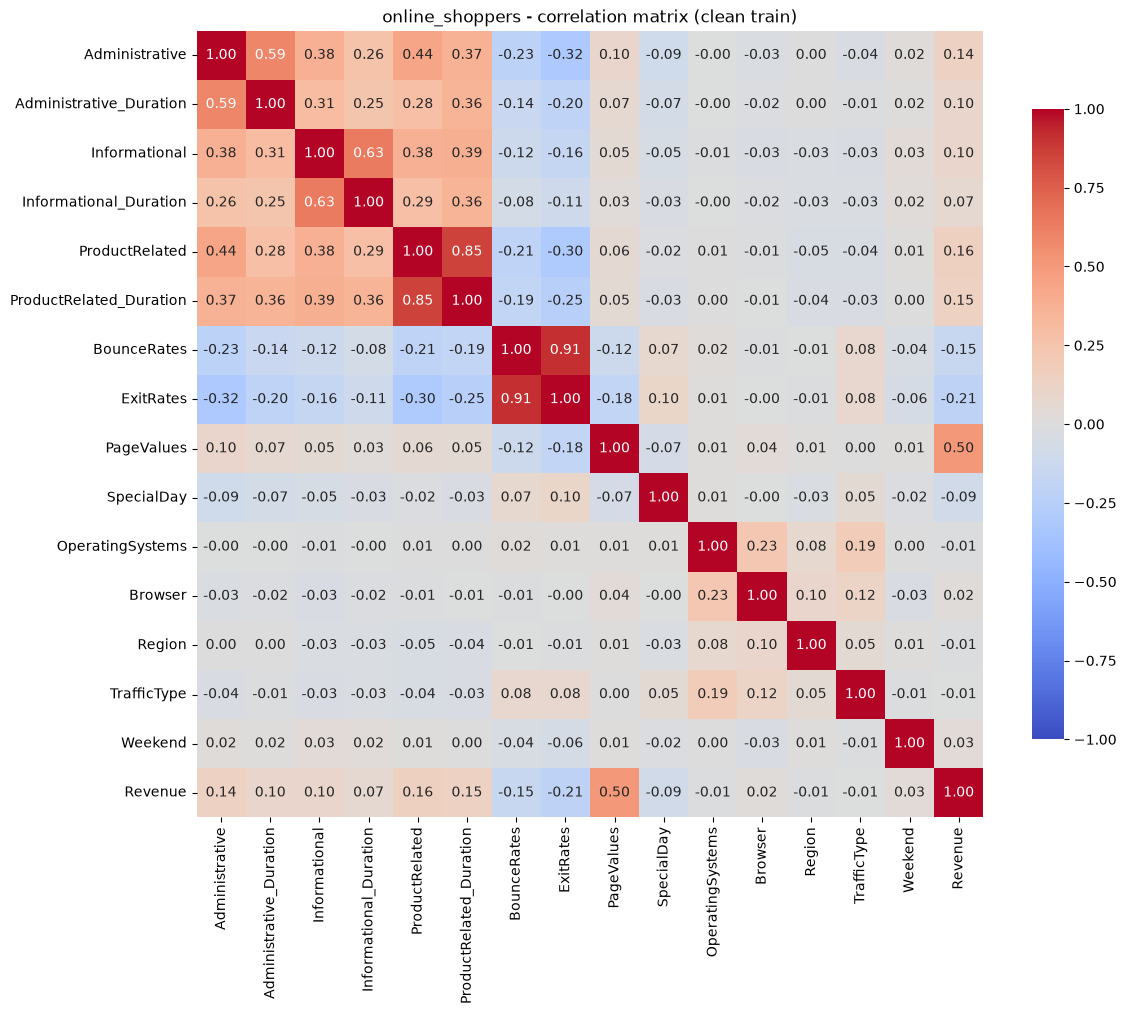

Correlation with y (per condition):
                         clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe   test
Administrative           0.143         0.147           0.143         0.112           0.078       0.131         0.068  0.124
Administrative_Duration  0.099         0.102           0.103         0.069           0.061       0.090         0.051  0.069
Informational            0.097         0.096           0.093         0.029           0.005       0.085         0.050  0.086
Informational_Duration   0.069         0.076           0.080         0.065           0.044       0.058         0.031  0.077
ProductRelated           0.156         0.161           0.161         0.118           0.083       0.135         0.073  0.170
ProductRelated_Duration  0.146         0.134           0.136         0.098           0.049       0.127         0.075  0.178
BounceRates             -0.154        -0.154          -0.155        -0.117          -0.078      

In [28]:
# 6. Correlation matrix
corr_cols = num_cols + CODES + [TARGET]

# 6a. Full heatmap - clean baseline
corr_clean = all_dfs["clean"][corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_clean, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8})
plt.title(f"{DATASET} - correlation matrix (clean train)")
plt.tight_layout()
plt.show()

# 6b. Correlation with target, per condition
target_corr = pd.DataFrame(
    {name: d[corr_cols].corr()[TARGET].drop(TARGET) for name, d in all_dfs.items()}
).round(3)

print("Correlation with y (per condition):")
print(target_corr.to_string())

# 6c. How much each condition distorts the whole matrix vs clean
distortion = pd.Series(
    {name: (d[corr_cols].corr() - corr_clean).abs().values.mean() for name, d in all_dfs.items()}
).round(4)

print("\nMean absolute change in correlation vs clean:")
print(distortion.to_string())

In [29]:
# 7. Catchable outliers (rule violations among injected values)
for cond in ["outlier_mild", "outlier_severe"]:
    d = all_dfs[cond]
    clean = all_dfs["clean"]
    print(f"\n{cond.upper()}")
    print(f"  {'column':<25} {'changed':>8} {'impossible':>11} {'catchable %':>12}")
    for col in CONT:
        lo, hi = BOUNDS.get(col, (None, None))
        changed = d[col] != clean[col]
        impossible = changed & rule_violations(d[col], lo, hi)
        n_changed = changed.sum()
        n_impossible = impossible.sum()
        share = n_impossible / n_changed * 100 if n_changed > 0 else 0
        print(f"  {col:<25} {n_changed:>8} {n_impossible:>11} {share:>11.1f}%")


OUTLIER_MILD
  column                     changed  impossible  catchable %
  Administrative                 491         234        47.7%
  Administrative_Duration        493         256        51.9%
  Informational                  493           0         0.0%
  Informational_Duration         493         226        45.8%
  ProductRelated                 493         260        52.7%
  ProductRelated_Duration        493         239        48.5%
  BounceRates                    493         227        46.0%
  ExitRates                      493         256        51.9%
  PageValues                     493         259        52.5%
  SpecialDay                     493         235        47.7%

OUTLIER_SEVERE
  column                     changed  impossible  catchable %
  Administrative                1472         738        50.1%
  Administrative_Duration       1480         747        50.5%
  Informational                 1480           0         0.0%
  Informational_Duration        1480    

In [30]:
# 8. Validity rules on clean data (must all be 0)
clean = all_dfs["clean"]
print("Rule violations on CLEAN training data (should all be 0):")
for col in BOUNDS:
    lo, hi = BOUNDS[col]
    n_bad = rule_violations(clean[col], lo, hi).sum()
    print(f"  {col:<25} {n_bad}")

Rule violations on CLEAN training data (should all be 0):
  Administrative            0
  Administrative_Duration   0
  Informational             0
  Informational_Duration    0
  ProductRelated            0
  ProductRelated_Duration   0
  BounceRates               0
  ExitRates                 0
  PageValues                0
  SpecialDay                0
  OperatingSystems          0
  Browser                   0
  Region                    0
  TrafficType               0
  Weekend                   0
